# Sandbox short-term validation: nSeg=4 equal vs. nSeg=5 unequal vs. measured data

Compares three `Buildings.Fluid.Geothermal.Borefields.Validation.Sandbox` variants (Beier et al.
2011 experiment, 18.3 m borehole, ~52 h of heat injection) against the measured reference data
(`Beier_Smith_Spitler_2011_SandBox.txt`):

- **`Sandbox`** - nSeg=10 equal segments (existing baseline).
- **`Sandbox_UnequalSegments`** - nSeg=5 unequal segments (`end_length_ratio=0.05`), the
  long-term-sizing-optimized distribution from `unequal_segmentation_exploration.ipynb`.
- **`Sandbox_Nseg4Equal`** - nSeg=4 equal segments, the cheaper candidate for the short-to-medium
  term LKCC_3 experiment tiers (Part 1c of the same notebook found this holds up for the
  long-term g-function through about 2 years).

Question: does `nSeg=4` equal also hold up for **short-term** (RC-network) dynamics against real
measured data, not just the long-term g-function?

Simulation results were generated via the Modelon Impact SDK (not importable from this
notebook's `pygfunction` kernel) and saved to CSV in `Data/` next to this notebook - see
`sandbox_{tag}.csv` for each variant, one row per output time step
(`time_s, TBorFieIn_K, TBorFieOut_K`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Data')

variants = {
    'nSeg=10 equal (baseline)': 'sandbox_nSeg10_equal.csv',
    'nSeg=5 unequal': 'sandbox_nSeg5_unequal.csv',
    'nSeg=4 equal': 'sandbox_nSeg4_equal.csv',
}

sim = {}
for label, fname in variants.items():
    arr = np.loadtxt(DATA_DIR / fname, delimiter=',', skiprows=1)
    t, t_in, t_out = arr[:, 0], arr[:, 1] - 273.15, arr[:, 2] - 273.15
    sim[label] = {'t': t, 'T_in': t_in, 'T_out': t_out}

# Measured data: time (s), two measured temperatures (degC), normalized heat-rate signal (0-1,
# not needed here - it's the input that drove the simulated heater, already baked into the sims).
BUILDINGS_ROOT = Path(
    '/home/jovyan/impact/local_projects/Modelica-buildings_7/Buildings/Resources/Data/Fluid/'
    'Geothermal/Borefields/HeatTransfer/Validation/Beier_Smith_Spitler_2011_SandBox.txt'
)
mea = np.loadtxt(BUILDINGS_ROOT, skiprows=2)
t_mea, T_mea_a, T_mea_b = mea[:, 0], mea[:, 1], mea[:, 2]

print(f"Measured data: {len(t_mea)} points, {t_mea[0]:.0f}-{t_mea[-1]:.0f} s "
      f"({t_mea[-1]/3600:.1f} h)")
for label, d in sim.items():
    print(f"{label:28s}: {len(d['t'])} points, {d['t'][0]:.0f}-{d['t'][-1]:.0f} s")

Measured data: 2832 points, 0-186360 s (51.8 h)
nSeg=10 equal (baseline)    : 8211 points, 0-186360 s
nSeg=5 unequal              : 8211 points, 0-186360 s
nSeg=4 equal                : 8211 points, 0-186360 s


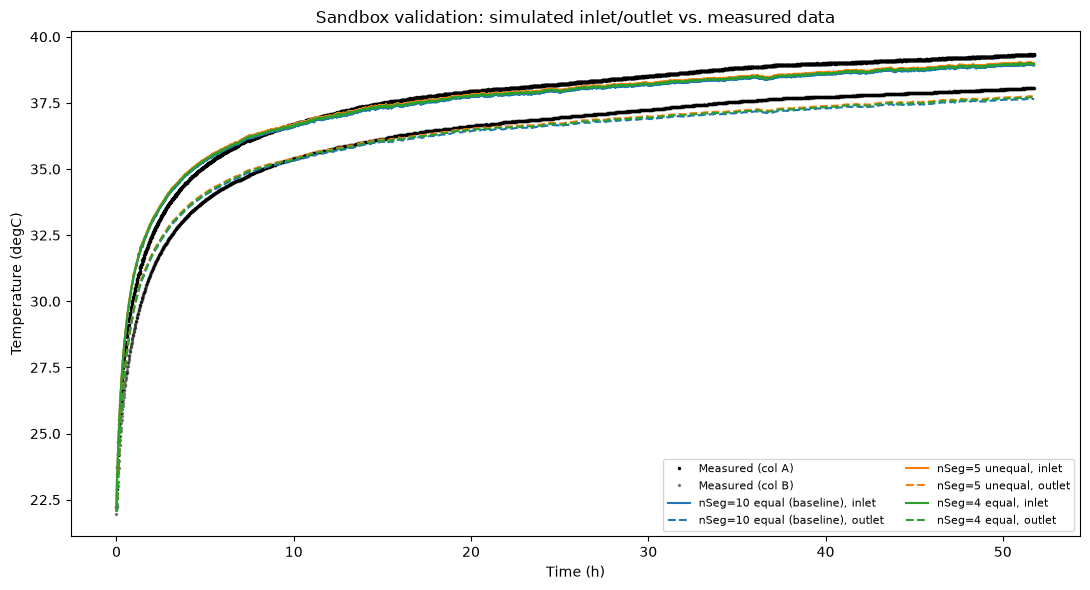

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(t_mea / 3600, T_mea_a, 'k.', markersize=3, label='Measured (col A)')
ax.plot(t_mea / 3600, T_mea_b, 'k.', markersize=3, alpha=0.4, label='Measured (col B)')

colors = {'nSeg=10 equal (baseline)': 'C0', 'nSeg=5 unequal': 'C1', 'nSeg=4 equal': 'C2'}
for label, d in sim.items():
    ax.plot(d['t'] / 3600, d['T_in'], color=colors[label], linestyle='-', label=f'{label}, inlet')
    ax.plot(d['t'] / 3600, d['T_out'], color=colors[label], linestyle='--', label=f'{label}, outlet')

ax.set_xlabel('Time (h)')
ax.set_ylabel('Temperature (degC)')
ax.set_title('Sandbox validation: simulated inlet/outlet vs. measured data')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Residuals vs. measured data

Interpolate each simulated inlet/outlet trajectory onto the measured time grid and compute the
absolute deviation against **both** measured columns, so the better-matching pairing (inlet vs.
column A/B, outlet vs. the other) becomes apparent from the numbers rather than assumed.

In [3]:
print(f"{'variant':28s} {'sim signal':10s} {'vs. mea A':>12s} {'vs. mea B':>12s}   (mean / max abs degC)")
for label, d in sim.items():
    for sig_name, sig in [('inlet', d['T_in']), ('outlet', d['T_out'])]:
        sig_interp = np.interp(t_mea, d['t'], sig)
        for mea_name, mea_sig in [('A', T_mea_a), ('B', T_mea_b)]:
            pass
    t_in_interp = np.interp(t_mea, d['t'], d['T_in'])
    t_out_interp = np.interp(t_mea, d['t'], d['T_out'])
    for sig_name, sig_interp in [('inlet', t_in_interp), ('outlet', t_out_interp)]:
        res_a = np.abs(sig_interp - T_mea_a)
        res_b = np.abs(sig_interp - T_mea_b)
        print(f"{label:28s} {sig_name:10s} {res_a.mean():5.3f}/{res_a.max():5.3f}  "
              f"{res_b.mean():5.3f}/{res_b.max():5.3f}")

variant                      sim signal    vs. mea A    vs. mea B   (mean / max abs degC)
nSeg=10 equal (baseline)     inlet      0.302/0.749  1.074/2.138
nSeg=10 equal (baseline)     outlet     1.487/1.781  0.309/0.814
nSeg=5 unequal               inlet      0.247/0.838  1.162/2.226
nSeg=5 unequal               outlet     1.399/1.693  0.254/0.891
nSeg=4 equal                 inlet      0.271/0.797  1.122/2.186
nSeg=4 equal                 outlet     1.439/1.732  0.278/0.852


## Observations

**Pairing**: simulated inlet matches measured column A (~0.25-0.30 mean abs degC across all three
variants), simulated outlet matches measured column B (~0.25-0.31 mean abs degC) - both pairings
are roughly 4-6x tighter than the mismatched pairing (~1.1-1.5 mean abs degC), so this is
unambiguous.

**`nSeg=4` equal is essentially indistinguishable from the `nSeg=10` equal baseline against real
measured data**:

| variant | inlet vs. measured A (mean/max degC) | outlet vs. measured B (mean/max degC) |
|---|---|---|
| nSeg=10 equal (baseline) | 0.302 / 0.749 | 0.309 / 0.814 |
| nSeg=5 unequal | 0.247 / 0.838 | 0.254 / 0.891 |
| nSeg=4 equal | 0.271 / 0.797 | 0.278 / 0.852 |

All three variants land within ~0.05 degC mean of each other - well inside the ~0.3-1.5 degC
model-vs-measurement gap itself (experimental uncertainty, model assumptions such as the
aluminum-pipe borehole wall, filling material properties not reported by Beier et al. and
estimated from a different source - see `Sandbox.mo`'s documentation). This matches the earlier
direct model-to-model short-term comparison from this project (nSeg=5 unequal vs. nSeg=10 equal,
without a measured reference: ~0.1 K max difference) - segmentation choice, in the 4-10 segment
range tested here, is not the dominant source of error against real data at all.

**Conclusion**: `nSeg=4` equal holds up short-term just as well as it held up long-term (Part 1c
of `unequal_segmentation_exploration.ipynb`, acceptable through ~2 years). Confirms `nSeg=4`
equal as the segmentation choice for the LKCC_3 short-to-medium-term experiment tiers (1 day
through 1 year), reserving `nSeg=5` unequal/`end_length_ratio=0.05` for the 20-year sizing tier
only.